# Visualização de Dados de Problemas Respiratórios em Canoas
Aqui serão montados e esboçados gráficos para o dashboard do streamlit

## Interações SUS por problemas respiratórios

In [1]:
import pandas as pd
import seaborn as sns
import datacleaning

df_sus = pd.read_csv('../../dataset/sus.csv')
df_sus = datacleaning.dataCleaningSus(df_sus)
df_sus_day = datacleaning.aggregateSusByDay(df_sus)
df_sus.head()

,MES_CMPT,ANO_CMPT,IDADE,SEXO,MORTE,PROC_REA,QT_DIARIAS,CNES,data,MES_ANO
0,1,2020,67,Feminino,Sim,303140151,3,2232014,2020-01-10,2020-01-01
1,1,2020,77,Masculino,Não,303140151,4,2232014,2020-01-18,2020-01-01
2,1,2020,70,Masculino,Sim,303140151,6,2232014,2020-01-11,2020-01-01
3,1,2020,66,Masculino,Não,303140151,18,2232014,2020-01-10,2020-01-01
4,1,2020,83,Feminino,Não,303140151,11,2232014,2020-01-08,2020-01-01


Aqui temos os códigos de quais procedimentos foram realizados

In [2]:
df_sus.PROC_REA.unique()

array([303140151, 303140135, 303140143, 303140089, 412040166, 303130032,
       303140046, 303060131, 404010377, 412030012, 412020084, 404010024,
       415020034, 303140100, 303140119, 303140038, 412010038, 303060174,
       412040174, 301060088, 303080094, 303140127, 415010012, 408050012,
       412020017, 412030098, 308040015, 412030101, 404010059, 303130067,
       308010035, 415040035, 304100021, 412010100, 412050102, 412010119,
       303010223, 308010019, 201010402, 404010032, 404010482, 404010016,
       415030013, 404010067, 407040161, 412020033, 303140054, 412010046,
       412050048, 303060255, 303150068, 412030110, 412050161, 407030140,
       404020534, 303080078, 404010415, 301060010, 401020100, 209040050,
       412050064, 209040033, 412010097, 303010037, 303080060, 412050013,
       303010215, 303040165, 303060212, 404010237, 303170131, 407010220,
       303060140, 404010504])

C:\Users\joaovitor\AppData\Local\Temp\ipykernel_8484\2307807892.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MES_ANO', y='Internações', data=df_counts, palette='viridis')


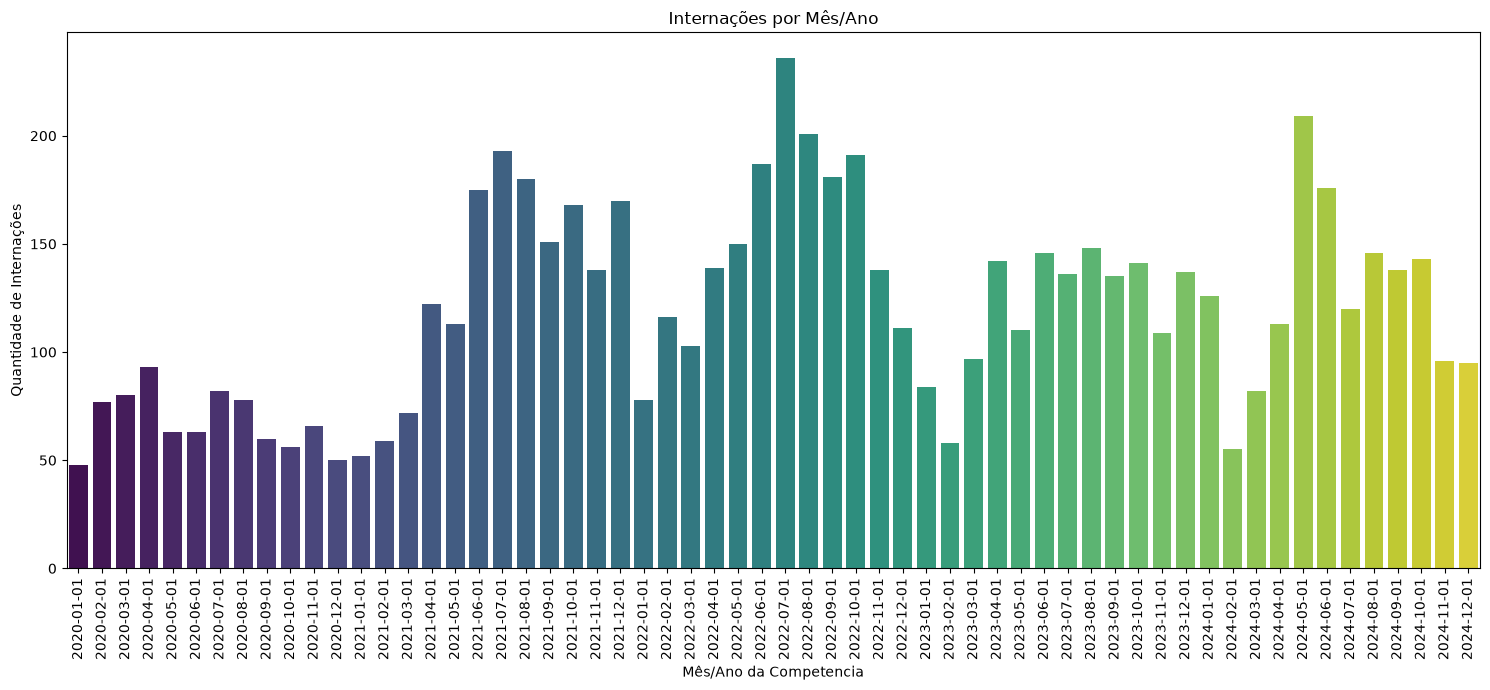

In [3]:
import matplotlib.pyplot as plt

# Calculate counts for each MES_ANO
df_counts = df_sus['MES_ANO'].value_counts().reset_index()
df_counts.columns = ['MES_ANO', 'Internações']

# Create a sortable datetime column for correct ordering
df_counts['MES_ANO_SORT'] = pd.to_datetime(df_counts['MES_ANO'], format='%m/%Y')

# Sort the DataFrame by the new datetime column
df_counts = df_counts.sort_values(by='MES_ANO_SORT')

# Create the column chart
plt.figure(figsize=(15, 7))
sns.barplot(x='MES_ANO', y='Internações', data=df_counts, palette='viridis')
plt.xlabel('Mês/Ano da Competencia')
plt.ylabel('Quantidade de Internações')
plt.title('Internações por Mês/Ano')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

C:\Users\joaovitor\AppData\Local\Temp\ipykernel_8484\3411386192.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MES_ANO', y='Mortes', data=df_counts, palette='viridis')


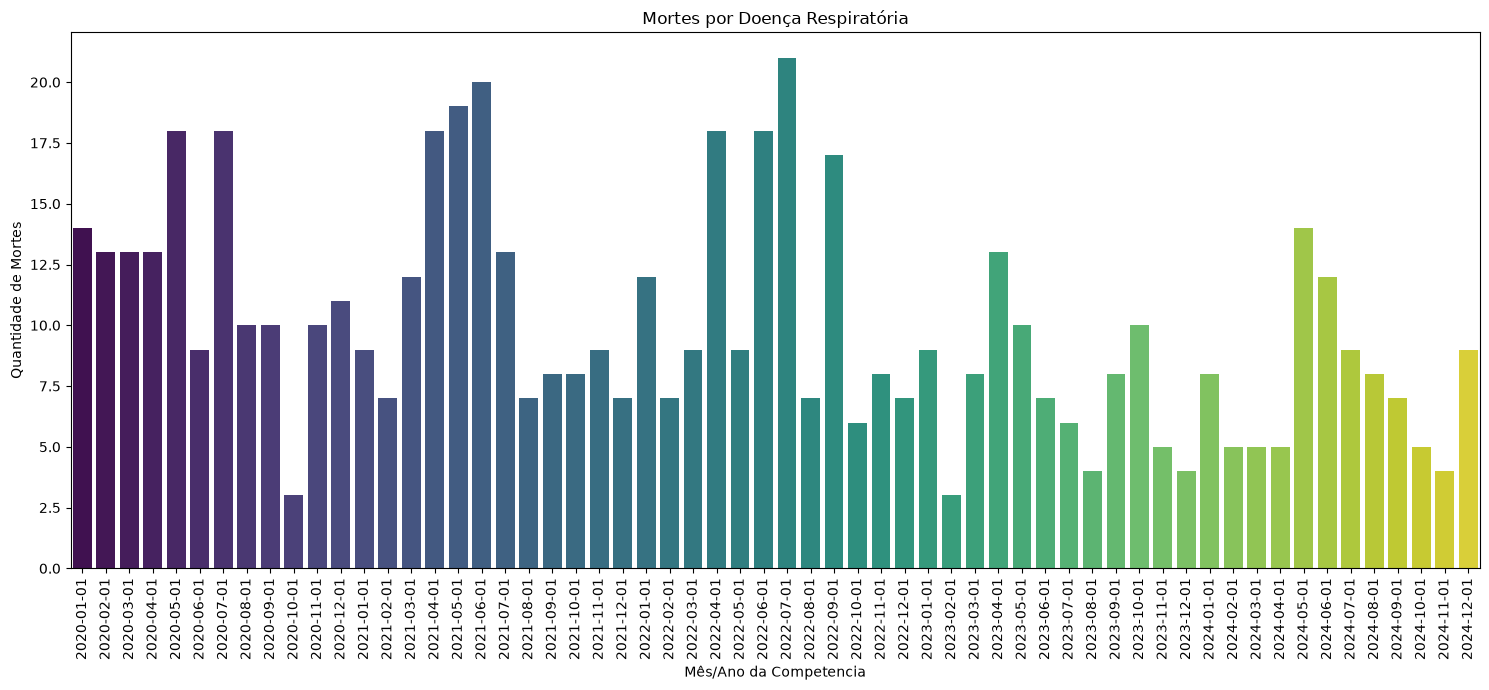

In [4]:
import matplotlib.pyplot as plt

# Calculate counts for each MES_ANO
df_mortes = df_sus[df_sus['MORTE']=='Sim']
df_counts = df_mortes['MES_ANO'].value_counts().reset_index()
df_counts.columns = ['MES_ANO', 'Mortes']

# Create a sortable datetime column for correct ordering
df_counts['MES_ANO_SORT'] = pd.to_datetime(df_counts['MES_ANO'], format='%m/%Y')

# Sort the DataFrame by the new datetime column
df_counts = df_counts.sort_values(by='MES_ANO_SORT')

# Create the column chart
plt.figure(figsize=(15, 7))
sns.barplot(x='MES_ANO', y='Mortes', data=df_counts, palette='viridis')
plt.xlabel('Mês/Ano da Competencia')
plt.ylabel('Quantidade de Mortes')
plt.title('Mortes por Doença Respiratória')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Fepam - Solo

In [5]:
df_fepam = pd.read_csv('../../dataset/fepam.csv')
df_fepam.info()

<class 'pandas.DataFrame'>
RangeIndex: 39095 entries, 0 to 39094
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   data    39095 non-null  str    
 1   pm10    21401 non-null  float64
 2   so2     38039 non-null  float64
 3   no2     37521 non-null  float64
 4   o3      37649 non-null  float64
 5   co      18494 non-null  float64
dtypes: float64(5), str(1)
memory usage: 2.5 MB


In [6]:
df_fepam = datacleaning.dataCleaningFepam(df_fepam)
df_fepam_day = datacleaning.aggregateFepamByDay(df_fepam)

c:\Users\joaovitor\Desktop\Guri-Teimoso\src\data-visualization\datacleaning.py:84: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  return df_fepam_day.round(2)


Lets see how the variables behave

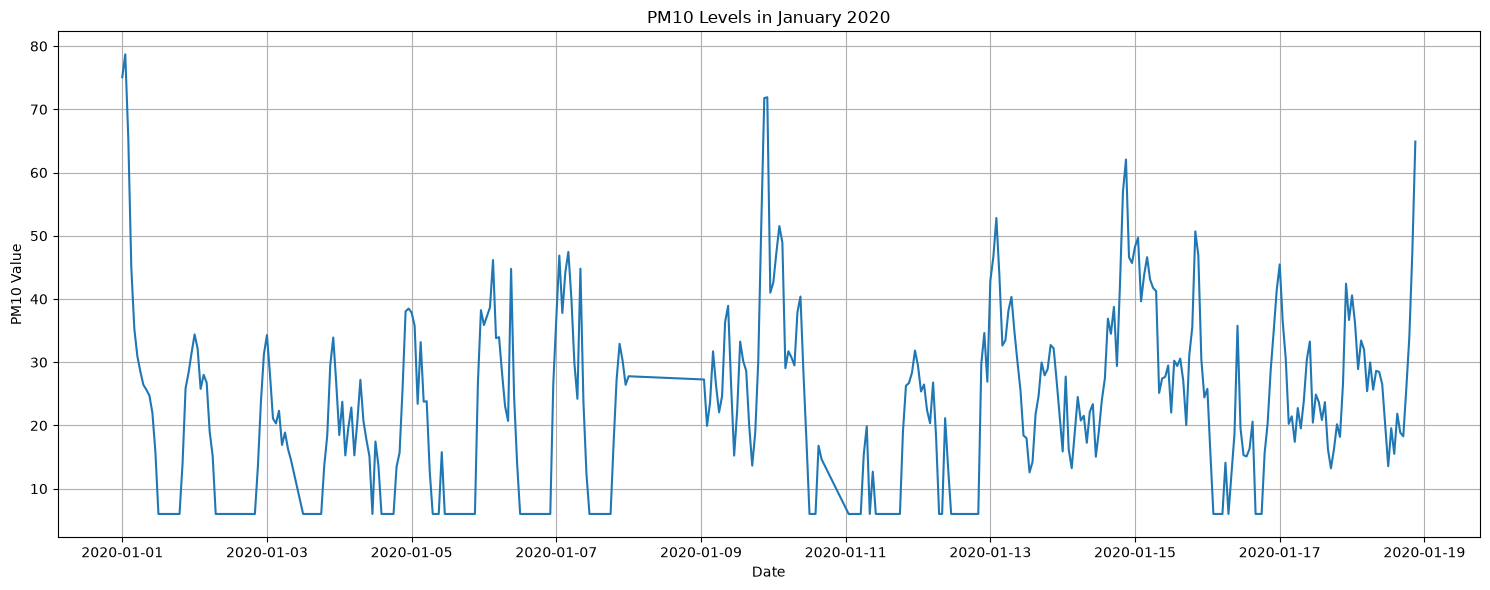

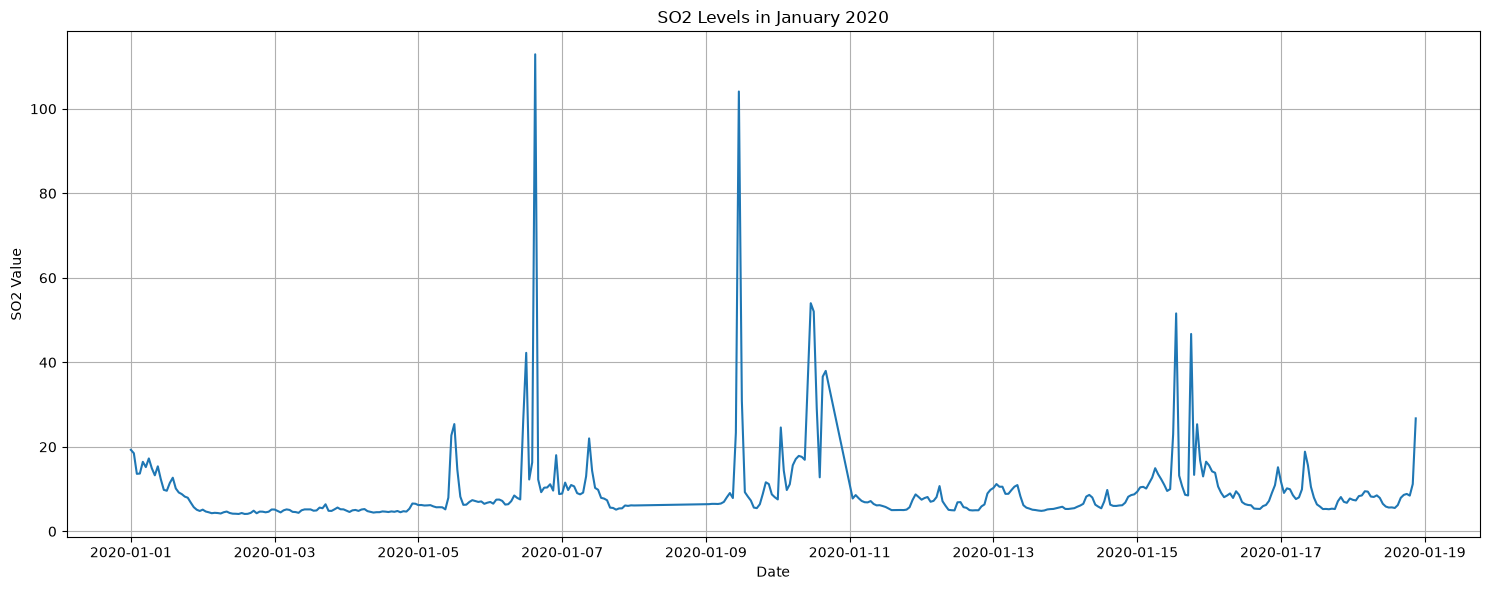

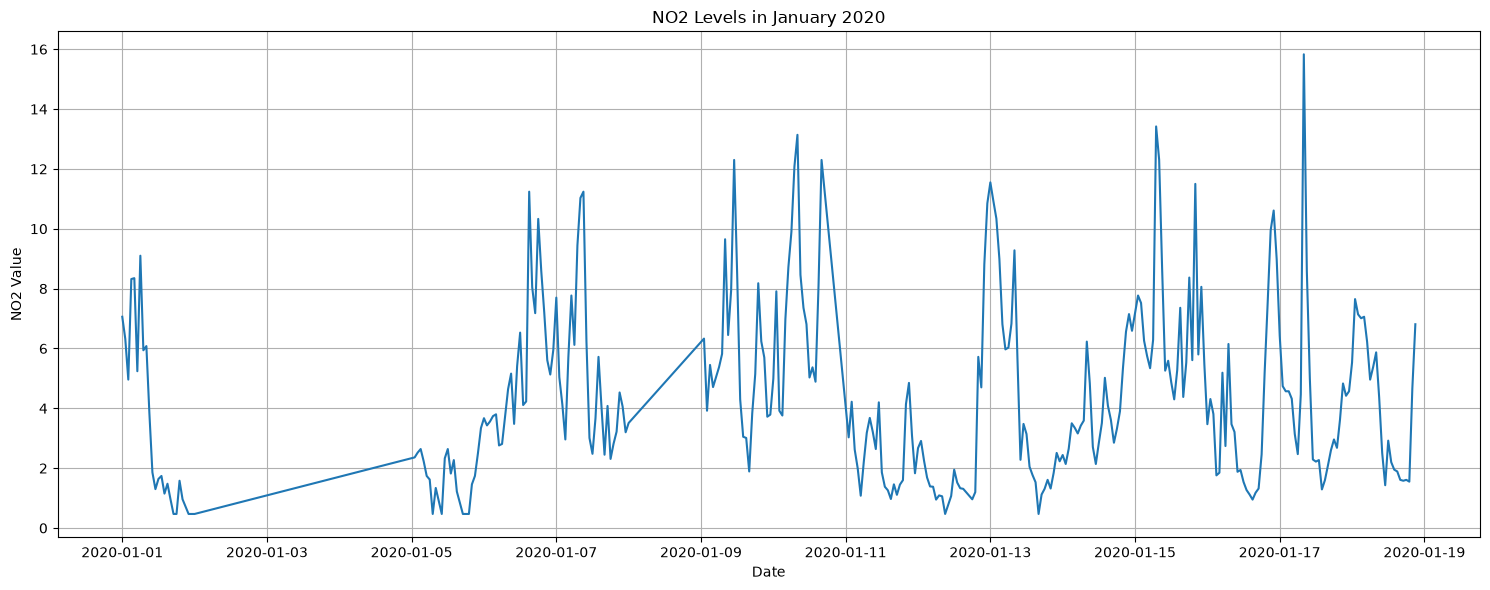

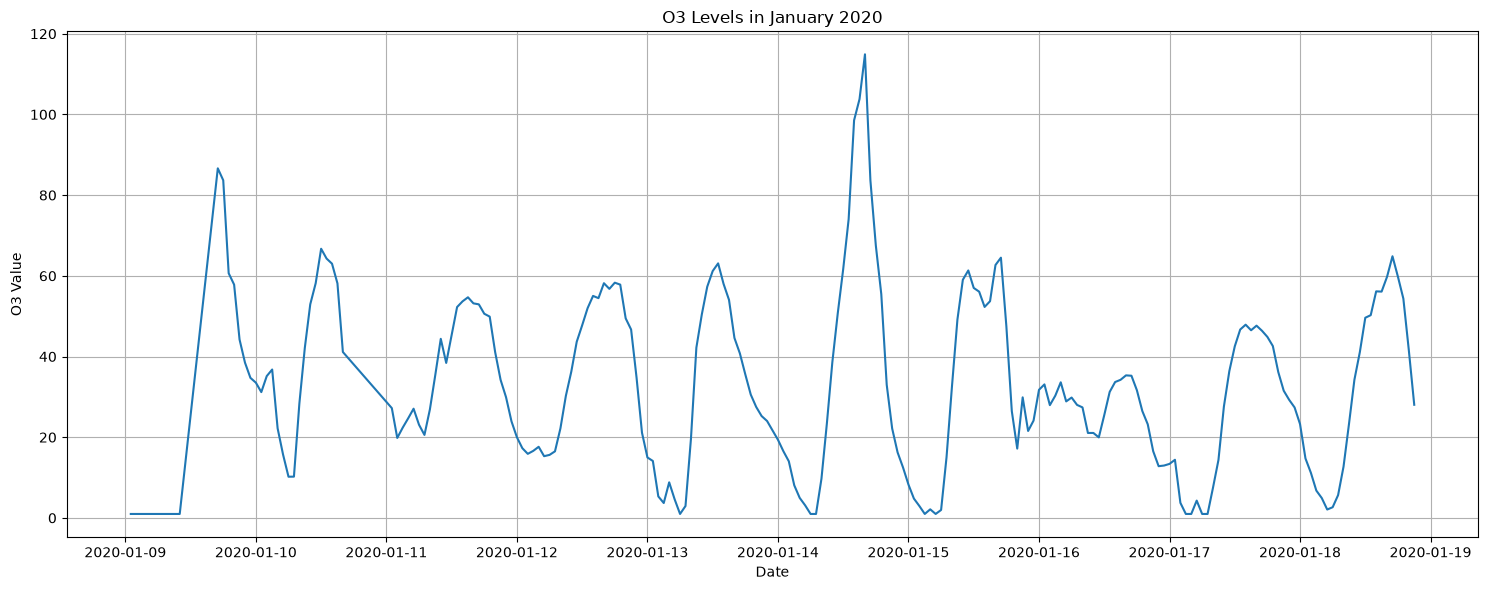

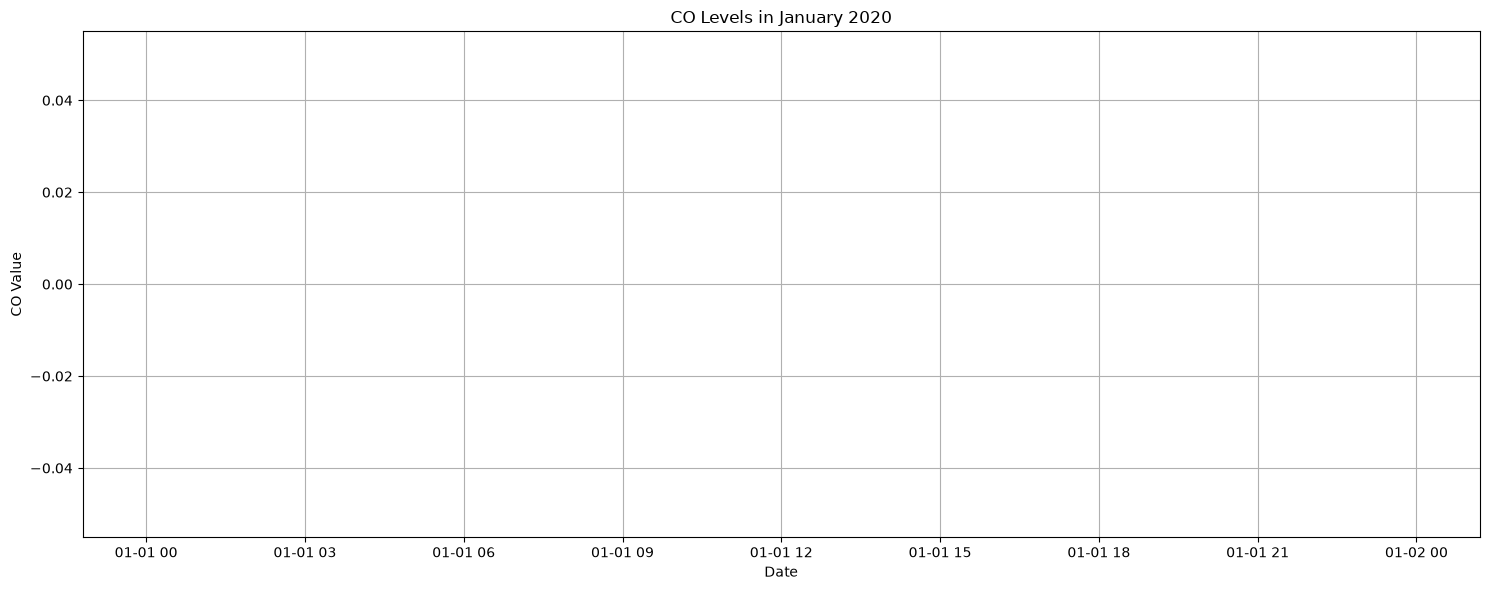

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for January 2020
df_fepam_jan2020 = df_fepam[(df_fepam['data'] >= '2020-01-01') & (df_fepam['data'] < '2020-02-01')]

# Metrics to plot
metrics = ['pm10', 'so2', 'no2', 'o3', 'co']

# Create a plot for each metric
for metric in metrics:
    plt.figure(figsize=(15, 6))
    sns.lineplot(x='data', y=metric, data=df_fepam_jan2020)
    plt.title(f'{metric.upper()} Levels in January 2020')
    plt.xlabel('Date')
    plt.ylabel(f'{metric.upper()} Value')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## Inmet

In [8]:
df_inmet = pd.read_csv('../../dataset/inmet.csv')
df_inmet = datacleaning.dataCleaningInmet(df_inmet)
df_inmet_day = datacleaning.aggregateInmetByDay(df_inmet)

c:\Users\joaovitor\Desktop\Guri-Teimoso\src\data-visualization\datacleaning.py:103: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  return df_inmet_day.round(2)


In [9]:
df_inmet.info()

<class 'pandas.DataFrame'>
RangeIndex: 43845 entries, 3 to 43847
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   data            43845 non-null  datetime64[us]
 1   precipitacao    43606 non-null  float64       
 2   pressao_atm     43605 non-null  float64       
 3   temperatura_ar  43605 non-null  float64       
 4   umidade_rel     43600 non-null  float64       
dtypes: datetime64[us](1), float64(4)
memory usage: 1.7 MB


In [10]:
df_inmet.head()

,data,precipitacao,pressao_atm,temperatura_ar,umidade_rel
3,2020-01-01 00:00:00,0.0,999.9,25.3,82.0
4,2020-01-01 01:00:00,0.0,999.2,25.1,81.0
5,2020-01-01 02:00:00,0.0,998.9,25.5,79.0
6,2020-01-01 03:00:00,0.0,998.8,25.1,81.0
7,2020-01-01 04:00:00,0.0,998.9,25.3,79.0


In [11]:
df_inmet_day

,data,precipitacao_mean,pressao_atm_mean,temperatura_ar_mean,umidade_rel_mean,faixa_temperatura
0,2020-01-01,0.00,999.80,27.14,74.12,Quente (22-28°C)
1,2020-01-02,0.06,1006.75,23.60,74.92,Quente (22-28°C)
2,2020-01-03,0.03,1010.77,22.94,72.38,Quente (22-28°C)
3,2020-01-04,0.01,1007.60,23.78,71.67,Quente (22-28°C)
4,2020-01-05,0.00,1001.40,25.46,67.83,Quente (22-28°C)
...,...,...,...,...,...,...
1822,2024-12-27,0.00,1005.02,23.51,62.67,Quente (22-28°C)
1823,2024-12-28,0.00,1008.58,23.26,71.96,Quente (22-28°C)
1824,2024-12-29,0.00,1009.42,22.55,74.33,Quente (22-28°C)
1825,2024-12-30,0.00,1007.32,23.31,74.12,Quente (22-28°C)


## Agregação

In [12]:
df_agg = datacleaning.joinTablesByDate(df_sus_day, df_fepam_day, df_inmet_day)

In [13]:
df_agg.head(5)

,data,precipitacao_mean,pressao_atm_mean,temperatura_ar_mean,umidade_rel_mean,faixa_temperatura,pm10_mean,so2_mean,no2_mean,o3_mean,co_mean,IQAr,qualidade_do_ar,volume_internacoes,volume_mortes
0,2020-01-01,0.00,999.80,27.14,74.12,Quente (22-28°C),25.88,11.68,3.60,NaN,NaN,23.0,Boa,0,0
1,2020-01-02,0.06,1006.75,23.60,74.92,Quente (22-28°C),13.91,4.48,0.47,NaN,NaN,12.0,Boa,0,0
2,2020-01-03,0.03,1010.77,22.94,72.38,Quente (22-28°C),16.98,5.09,NaN,NaN,NaN,15.0,Boa,4,2
3,2020-01-04,0.01,1007.60,23.78,71.67,Quente (22-28°C),17.31,4.93,NaN,NaN,NaN,15.0,Boa,4,1
4,2020-01-05,0.00,1001.40,25.46,67.83,Quente (22-28°C),14.81,8.31,1.72,NaN,NaN,13.0,Boa,2,1


In [14]:
import altair as alt
import pandas as pd
from plots import *


plot_internations_vs_temperature_evolution(df_agg)

alt.LayerChart(...)

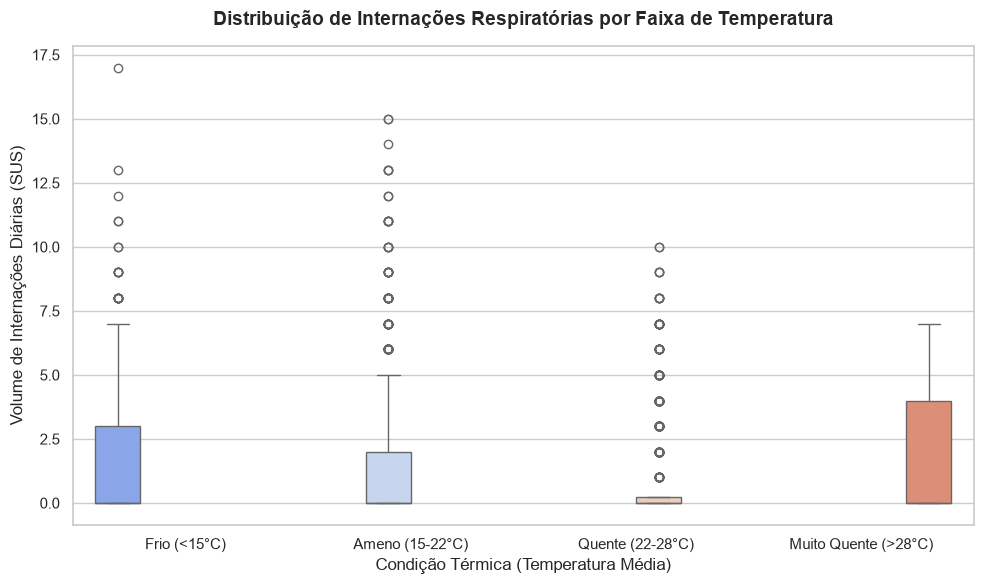

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configura o estilo visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Cria o Boxplot
sns.boxplot(
    data=df_agg, 
    x='faixa_temperatura', 
    y='volume_internacoes', 
    palette='coolwarm',  # Vai criar um degradê natural do azul (frio) ao vermelho (quente)
    hue='faixa_temperatura',
    legend=False
)

# Ajustes de títulos e eixos
plt.title('Distribuição de Internações Respiratórias por Faixa de Temperatura', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Condição Térmica (Temperatura Média)', fontsize=12)
plt.ylabel('Volume de Internações Diárias (SUS)', fontsize=12)

plt.tight_layout()
plt.show()

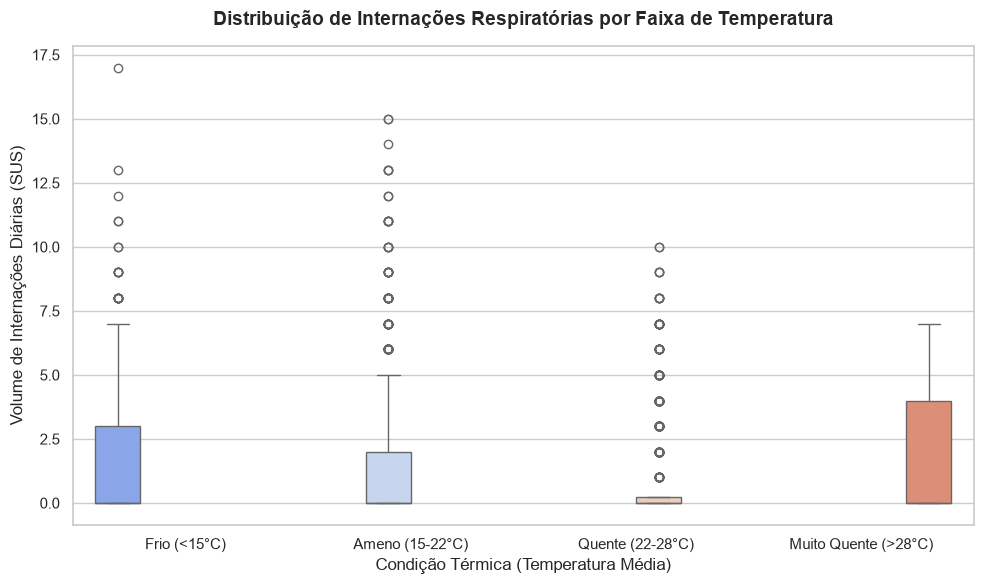

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configura o estilo visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Cria o Boxplot
sns.boxplot(
    data=df_agg, 
    x='faixa_temperatura', 
    y='volume_internacoes', 
    palette='coolwarm',  # Vai criar um degradê natural do azul (frio) ao vermelho (quente)
    hue='faixa_temperatura',
    legend=False
)

# Ajustes de títulos e eixos
plt.title('Distribuição de Internações Respiratórias por Faixa de Temperatura', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Condição Térmica (Temperatura Média)', fontsize=12)
plt.ylabel('Volume de Internações Diárias (SUS)', fontsize=12)

plt.tight_layout()
plt.show()

C:\Users\joaovitor\AppData\Local\Temp\ipykernel_8484\2492385424.py:19: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.boxplot(


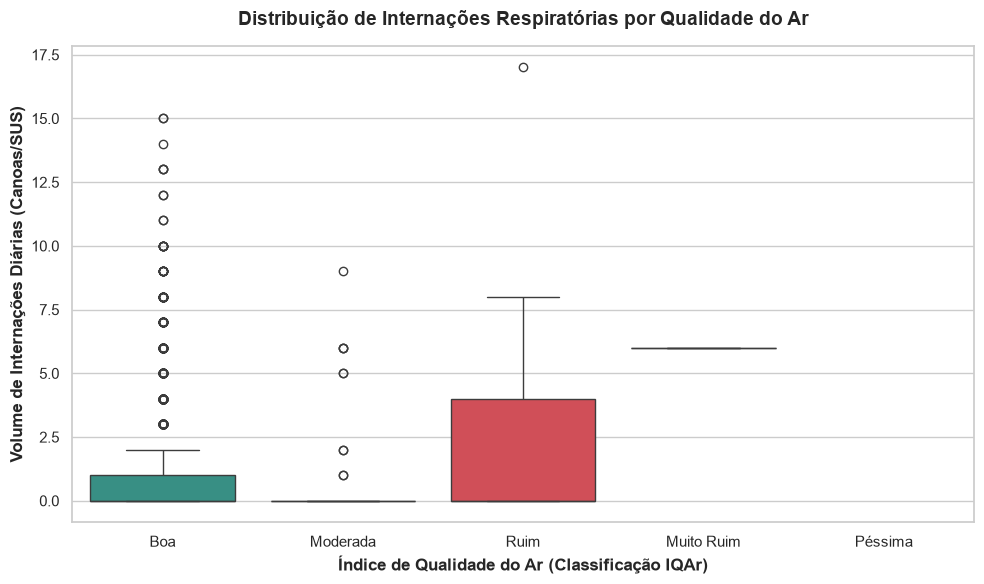

In [17]:
df_plot = df_agg.copy()
    
# 1. Definir a ordem lógica e epidemiológica das categorias
ordem_categorias = ["Boa", "Moderada", "Ruim", "Muito Ruim", "Péssima"]

# Filtrar o dataframe para garantir que só categorias válidas e presentes sejam plotadas
# (Evita que o "Sem Dados" ou categorias vazias poluam o gráfico)
df_plot = df_plot[df_plot['qualidade_do_ar'].isin(ordem_categorias)]

# 2. Configurar o estilo do gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Palette personalizada simulando as cores do Semáforo da Saúde do IQAr
# Verde (Boa), Amarelo (Moderada), Laranja (Ruim), Vermelho (Muito Ruim), Roxo (Péssima)
cores_iqar = ["#2A9D8F", "#E9C46A", "#F4A261", "#E63946", "#A855F7"]

# 3. Construir o Boxplot
sns.boxplot(
    data=df_plot,
    x='qualidade_do_ar',
    y='volume_internacoes',
    order=ordem_categorias,  # Força a ordem correta no eixo X
    palette=cores_iqar,      # Aplica as cores oficiais do índice
    hue='qualidade_do_ar',
    legend=False
)

# 4. Ajustes de títulos e rótulos dos eixos
plt.title('Distribuição de Internações Respiratórias por Qualidade do Ar', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Índice de Qualidade do Ar (Classificação IQAr)', fontsize=12, fontweight='bold')
plt.ylabel('Volume de Internações Diárias (Canoas/SUS)', fontsize=12, fontweight='bold')

# Ajusta o layout para não cortar nenhuma informação
plt.tight_layout()
plt.show()

In [ ]:
df_agg.to_csv("df_agg.csv", index=False)

#